# Lab 12：只告訴它好不好——GRPO、KL 懲罰與 DPO

對應講義：[第 12 課](../lessons/12_rl_and_preferences.md)

需要 Lab 11 的 `checkpoints/sft_model.pt`。

**任務**：使用者說「Tell me a story about a *cat*.」，SFT 模型會寫一篇故事，但常常寫著寫著就忘了貓。
獎勵是一條程式規則：**回答的前 40 個 token 有沒有提到那個主題字**（單複數都算）。這是「可驗證的獎勵」（講義 §2.5），不需要人、也不需要獎勵模型。

1. 起點：SFT 模型的平均獎勵、greedy、pass@k（式 12.11）
2. GRPO（nanochat 的簡化版）：每個 prompt 抽 16 篇，比組內平均好的加強、差的減弱
3. 結果：訓練過的主題 vs **沒看過的主題**；pass@k 曲線；**獎勵被鑽漏洞**（講義 §2.7）
4. 加上 KL 懲罰（式 12.1、12.10）：拉住模型，不要離 SFT 太遠
5. DPO（式 12.8）：用 SFT 自己的樣本組成「提到 vs 沒提到」的偏好配對，離線訓練
6. 比較
7. 為什麼不拿 Lab 11 的加法題做 RL？——一個在小模型上失敗的實驗，以及原因

CPU 約 12 分鐘。

In [1]:
import copy
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

from lm_course.utils import CHECKPOINT_DIR, notebook_logging, set_seed

%matplotlib inline
plt.rcParams["figure.dpi"] = 80
notebook_logging()
set_seed(0)

In [2]:
from lm_course.artifacts import course_tokenizer
from lm_course.chat import HELD_OUT_TOPICS, STORY_TOPICS, mentions_topic, render_for_completion, story_request
from lm_course.model import load_model

tok = course_tokenizer()
sft_model, _ = load_model(CHECKPOINT_DIR / "sft_model.pt")
sft_model.eval()
END = tok.special_id("<|assistant_end|>")
MAX_TOKENS = 40
print(f"{len(STORY_TOPICS)} training topics: {STORY_TOPICS}")
print(f"{len(HELD_OUT_TOPICS)} held-out topics (never used for training): {HELD_OUT_TOPICS}")

20 training topics: ['dog', 'cat', 'ball', 'tree', 'bird', 'park', 'cake', 'boat', 'flower', 'friend', 'toy', 'garden', 'rain', 'sun', 'fish', 'car', 'moon', 'box', 'hat', 'bear']
10 held-out topics (never used for training): ['frog', 'kite', 'apple', 'star', 'duck', 'train', 'doll', 'horse', 'shoe', 'bike']


訓練用的 20 個主題就是 Lab 11 SFT 資料裡用過的主題；另外 10 個主題**完全不參與訓練**，只用來檢查學到的行為能不能推廣。

## 1. 起點

先看 SFT 模型對「cat」抽 6 篇（temperature 1）的開頭，以及每篇的獎勵。

In [3]:
from lm_course.sampling import generate


def prompt_ids(topic: str) -> list[int]:
    return render_for_completion(tok, story_request(topic))


def reply_text(completion: list[int]) -> str:
    return tok.decode([t for t in completion if t != END])


g = torch.Generator().manual_seed(0)
for completion in generate(sft_model, prompt_ids("cat"), MAX_TOKENS, temperature=1.0, num_samples=6, stop_tokens={END}, generator=g):
    text = reply_text(completion)
    print(f"reward {mentions_topic('cat', text):.0f} | {text!r}")

reward 0 | 'Once upon a time, there was a moral of the story: why is all the other writes in the class. The other Ws loved to play together and have fun.'
reward 1 | 'One day, a clever cat named Tom went out to play. He saw a big box in the street. Tom wanted to say hello to the box. But he did not know how.\nTom tried'
reward 1 | 'Once upon a time, there was a beautiful cat. The cat liked to eat yummy food. One day, the his cat went for a walk in the park.\nWhile he was eating, something funny'
reward 1 | 'Once upon a time, there was a big forever. ball liked to step in the sunshine. One day, the ball saw a little cat come from the light. The cat was lost and dull.\n'
reward 1 | 'Once upon a time, there was a cute little cat named Tim. Tim had Why can run and play all day. He lived in a big park with many other cats. Tim loved to eat crying'
reward 1 | 'Once upon a time, in a distant land, there was a gray cat. The cat was red and smooth. The cat saw a big sandwich. The bird wanted so

「cat」算是容易的主題，大多數都有提到；下面把所有主題平均起來，情況就差多了。

評估函式：每個主題以 temperature 1 抽 16 篇，量四件事——

- **T=1 reward**：平均獎勵（＝抽一次就提到主題的機率，pass@1）
- **greedy**：greedy 解碼時提到主題的比例
- **repetition**：同一篇裡重複出現的相鄰詞對（bigram）比例——用來抓「鑽漏洞」
- **KL/token**：和 SFT 模型的距離，式 (12.1) 裡的那一項；在模型自己的樣本上平均 $\log \pi_\theta - \log \pi_{\text{SFT}}$

In [4]:
from lm_course.rl import completion_logprobs


def repetition(texts: list[str]) -> float:
    fractions = []
    for text in texts:
        words = text.lower().split()
        bigrams = list(zip(words, words[1:]))
        if bigrams:
            fractions.append(1 - len(set(bigrams)) / len(bigrams))
    return float(np.mean(fractions))


def evaluate(model: torch.nn.Module, topics: list[str], n: int = 16, seed: int = 0) -> dict[str, float]:
    g = torch.Generator().manual_seed(seed)
    rewards, greedy, texts, kls = [], [], [], []
    for topic in topics:
        prompt = prompt_ids(topic)
        completions = generate(model, prompt, MAX_TOKENS, temperature=1.0, num_samples=n, stop_tokens={END}, generator=g)
        texts += [reply_text(c) for c in completions]
        rewards.append(np.mean([mentions_topic(topic, reply_text(c)) for c in completions]))
        with torch.no_grad():
            logprobs, mask = completion_logprobs(model, prompt, completions, pad_id=END)
            reference, _ = completion_logprobs(sft_model, prompt, completions, pad_id=END)
        kls.append(((logprobs - reference) * mask).sum().item() / mask.sum().item())
        greedy.append(mentions_topic(topic, reply_text(generate(model, prompt, MAX_TOKENS, temperature=0.0, stop_tokens={END})[0])))
    return {"T=1 reward": float(np.mean(rewards)), "greedy": float(np.mean(greedy)),
            "repetition": repetition(texts), "KL/token": float(np.mean(kls))}


def show(name: str, model: torch.nn.Module) -> dict[str, dict[str, float]]:
    result = {"train": evaluate(model, STORY_TOPICS), "held-out": evaluate(model, HELD_OUT_TOPICS)}
    for split, r in result.items():
        print(f"{name:<14}{split:<9}" + "  ".join(f"{k} {v:.3f}" for k, v in r.items()))
    return result


summary = {"SFT": show("SFT", sft_model)}

SFT           train    T=1 reward 0.362  greedy 0.700  repetition 0.019  KL/token 0.000
SFT           held-out T=1 reward 0.131  greedy 0.300  repetition 0.019  KL/token 0.000


再用式 (12.11) 看 pass@k：在沒看過的主題上，每個主題抽 32 篇。

In [5]:
from lm_course.rl import pass_at_k


def pass_curve(model: torch.nn.Module, topics: list[str], n: int = 32) -> np.ndarray:
    g = torch.Generator().manual_seed(1)
    counts = []
    for topic in topics:
        completions = generate(model, prompt_ids(topic), MAX_TOKENS, temperature=1.0, num_samples=n, stop_tokens={END}, generator=g)
        counts.append(sum(mentions_topic(topic, reply_text(c)) for c in completions))
    return np.array([[pass_at_k(n, c, k) for k in range(1, n + 1)] for c in counts]).mean(axis=0)


curve_sft = pass_curve(sft_model, HELD_OUT_TOPICS)
print("SFT, held-out topics: " + ", ".join(f"pass@{k} {curve_sft[k - 1]:.2f}" for k in (1, 4, 16, 32)))

SFT, held-out topics: pass@1 0.13, pass@4 0.37, pass@16 0.74, pass@32 0.90


抽一次很少提到主題，但抽 32 次幾乎每個主題都至少有一篇提到——**模型「會」，只是不穩**。這正是 RL 能利用的空間：同一個 prompt 的 16 篇裡通常有好有壞，組內比較就有訊號。

## 2. GRPO（nanochat 式）

每一步：抽 8 個訓練主題，每個主題抽 $G = 16$ 篇（temperature 1）；advantage = 獎勵減去同組平均（不除以標準差）；loss 在所有回答 token 上平均（`policy_gradient_loss`）；每批樣本只更新一次（on-policy，所以就是 REINFORCE）。
整組都有提到或都沒提到的 prompt，advantage 全為 0，自動跳過。AdamW、學習率 3e-5、前 10 步 warmup、60 步。

`beta > 0` 時再加上 KL 懲罰（第 4 節用）。

In [6]:
from lm_course.optim import build_optimizer
from lm_course.rl import group_advantages, kl_penalty, policy_gradient_loss

RL_STEPS, PROMPTS, G, WARMUP = 60, 8, 16, 10


def grpo(beta: float = 0.0, lr: float = 3e-5) -> tuple[torch.nn.Module, dict[str, list[float]]]:
    set_seed(0)
    policy = copy.deepcopy(sft_model)
    optimizer = build_optimizer(policy, "adamw", lr=lr, weight_decay=0.0)
    rng = random.Random(0)
    g = torch.Generator().manual_seed(1)
    history = {"reward": [], "no signal": [], "kl": []}
    start = time.perf_counter()
    for step in range(RL_STEPS):
        optimizer.set_lr_multiplier(min(1.0, (step + 1) / WARMUP))
        optimizer.zero_grad()
        policy.train()
        rewards_this_step, no_signal, kls = [], 0, []
        for _ in range(PROMPTS):
            topic = rng.choice(STORY_TOPICS)
            prompt = prompt_ids(topic)
            with torch.no_grad():
                completions = generate(policy, prompt, MAX_TOKENS, temperature=1.0, num_samples=G, stop_tokens={END}, generator=g)
            rewards = torch.tensor([mentions_topic(topic, reply_text(c)) for c in completions])
            rewards_this_step.append(rewards.mean().item())
            advantages = group_advantages(rewards)
            no_signal += int(advantages.abs().sum() == 0)
            if advantages.abs().sum() == 0 and beta == 0:
                continue
            logprobs, mask = completion_logprobs(policy, prompt, completions, pad_id=END)
            loss = policy_gradient_loss(logprobs, advantages, mask)
            if beta > 0:
                with torch.no_grad():
                    reference, _ = completion_logprobs(sft_model, prompt, completions, pad_id=END)
                kl = kl_penalty(logprobs, reference, mask)
                kls.append(kl.item())
                loss = loss + beta * kl
            (loss / PROMPTS).backward()
        torch.nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
        optimizer.step()
        history["reward"].append(float(np.mean(rewards_this_step)))
        history["no signal"].append(no_signal)
        history["kl"].append(float(np.mean(kls)) if kls else 0.0)
        if (step + 1) % 10 == 0:
            print(f"step {step + 1}: mean reward {np.mean(history['reward'][-10:]):.3f}, "
                  f"prompts with no signal {np.mean(history['no signal'][-10:]):.1f}/{PROMPTS} "
                  f"({time.perf_counter() - start:.0f}s)")
    policy.eval()
    return policy, history


grpo_model, grpo_history = grpo(beta=0.0)

step 10: mean reward 0.343, prompts with no signal 0.2/8 (22s)


step 20: mean reward 0.453, prompts with no signal 0.0/8 (44s)


step 30: mean reward 0.501, prompts with no signal 0.0/8 (66s)


step 40: mean reward 0.643, prompts with no signal 0.0/8 (88s)


step 50: mean reward 0.712, prompts with no signal 0.2/8 (110s)


step 60: mean reward 0.786, prompts with no signal 1.2/8 (131s)


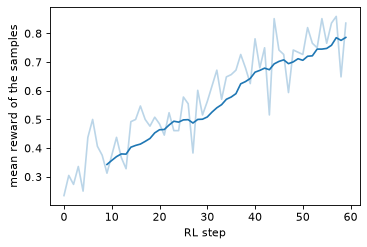

In [7]:
def smooth(values: list[float], width: int = 10) -> np.ndarray:
    return np.convolve(values, np.ones(width) / width, mode="valid")


plt.figure(figsize=(5, 3.2))
plt.plot(grpo_history["reward"], alpha=0.3, color="tab:blue")
plt.plot(np.arange(9, RL_STEPS), smooth(grpo_history["reward"]), color="tab:blue")
plt.xlabel("RL step")
plt.ylabel("mean reward of the samples")
plt.show()

## 3. 結果

### 3.1 數字

In [8]:
summary["GRPO"] = show("GRPO", grpo_model)

GRPO          train    T=1 reward 0.812  greedy 0.950  repetition 0.041  KL/token 0.065
GRPO          held-out T=1 reward 0.469  greedy 0.600  repetition 0.028  KL/token 0.051


獎勵明顯上升，**沒看過的主題也跟著進步**：模型學到的不是「cat 要提到 cat」這種個別規則，而是「使用者說什麼主題，開頭就寫那個主題」這個共通的行為。
但 repetition 與 KL 也上升了——模型變了多少、變成什麼樣子？直接看 greedy 輸出。

### 3.2 獎勵被鑽漏洞

In [9]:
for topic in ["cat", "sun", "kite", "horse"]:
    print(f"--- {topic} ---")
    for name, model in [("SFT", sft_model), ("GRPO", grpo_model)]:
        out = generate(model, prompt_ids(topic), 60, temperature=0.0, stop_tokens={END})[0]
        print(f"{name:>5}: {reply_text(out)!r}")

--- cat ---
  SFT: 'Once upon a time, there was a little girl named Lily. She had a big, red ball. Lily loved to play with her ball every day. One day, she saw a big, red ball in the park.\nLily wanted to play with the ball, but she was scared. She did'


 GRPO: 'Once upon a time, there was a cat named Tom. Tom was a very good cat. He liked to play with his ball. One day, Tom saw a big cat. The cat was very nice.\nTom wanted to play with the cat. He said, "Hi, cat! I like'
--- sun ---
  SFT: 'Once upon a time, there was a little girl named Lily. She had a big, red ball. Lily loved to play with her ball every day. One day, she saw a big, red ball in the park.\nLily wanted to play with the ball, but she was scared. She did'


 GRPO: 'Once upon a time, there was a big sun in the sky. It was a sunny day, and the sun was shining. The sun was shining, and the sky was blue.\nOne day, a little girl named Lily went to the park. She saw a big tree with a pretty flower.'
--- kite ---
  SFT: 'Once upon a time, there was a little girl named Lily. She had a big, red ball. Lily loved to play with her ball every day. One day, she saw a big, red ball in the park.\nLily wanted to play with the ball. She ran to the ball and tried'


 GRPO: 'Once upon a time, there was a big, red kite. It was very pretty. It liked to fly high in the sky. One day, the kite went to the park to play with the kite.\nAt the park, the kite met a little boy. The boy said, "Hi,'
--- horse ---
  SFT: 'Once upon a time, there was a little boy named Tim. Tim had a big, red barn. He loved to play with his friends in the barn. One day, Tim saw a big red barn near his house.\nTim wanted to go inside the barn. He asked his friends, "Can'


 GRPO: 'Once upon a time, there was a big horse. The horse liked to play with a big horse. One day, the horse went to the horse and said, "Hi, big horse!"\nThe horse was very happy. It liked to jump and run. The horse and the horse played all day'


獎勵只問「有沒有提到」，於是模型學會**一直提到**：主題字塞進每一句，甚至寫出「the horse went to the horse」「The horse and the horse played all day」這種不通的句子。獎勵很高，故事卻變差了——這就是講義 §2.7 的 reward hacking，只是規模小到一眼就看得出來。
獎勵函數只是我們真正想要的東西（好故事、而且切題）的**代理**；最佳化得越用力，兩者的差距就越會被放大（Gao 等人 2022）。

### 3.3 pass@k：RL 讓分布變尖

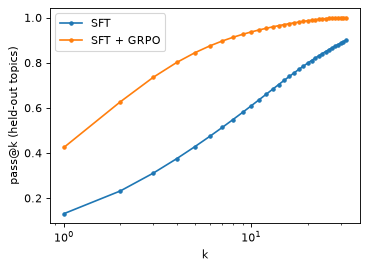

pass@1 : SFT 0.13, GRPO 0.42
pass@4 : SFT 0.37, GRPO 0.80
pass@16: SFT 0.74, GRPO 0.97
pass@32: SFT 0.90, GRPO 1.00


In [10]:
curve_grpo = pass_curve(grpo_model, HELD_OUT_TOPICS)
ks = np.arange(1, 33)
plt.figure(figsize=(5, 3.5))
plt.semilogx(ks, curve_sft, "o-", ms=3, label="SFT")
plt.semilogx(ks, curve_grpo, "o-", ms=3, label="SFT + GRPO")
plt.xlabel("k")
plt.ylabel("pass@k (held-out topics)")
plt.legend()
plt.show()
for k in (1, 4, 16, 32):
    print(f"pass@{k:<2}: SFT {curve_sft[k - 1]:.2f}, GRPO {curve_grpo[k - 1]:.2f}")

小 $k$ 的差距很大，$k$ 越大差距越小：RL 主要是把模型本來就「偶爾做得到」的行為，變成「每次都做」。這和 Yue 等人（2025）在大模型數學題上的觀察同一個方向（講義 §2.6）；不過在這裡 RL 之後的模型到 $k = 32$ 仍然略高，沒有被 SFT 模型追上。

## 4. 加上 KL 懲罰

式 (12.1) 的第二項：不要離 SFT 模型太遠。實作上用抽樣估計——在模型自己的樣本上，每個 token 算 $\frac{\pi_{\text{ref}}}{\pi_\theta} - \log\frac{\pi_{\text{ref}}}{\pi_\theta} - 1$（式 12.10；DeepSeekMath 的 GRPO 用的就是這個），它永遠 $\ge 0$、期望值正好是 KL（`tests/test_chat_and_rl.py` 驗證）。
其餘設定完全相同，只多了 $\beta = 0.1$。

In [11]:
kl_model, kl_history = grpo(beta=0.1)
summary["GRPO + KL"] = show("GRPO + KL", kl_model)

step 10: mean reward 0.343, prompts with no signal 0.2/8 (25s)


step 20: mean reward 0.448, prompts with no signal 0.0/8 (49s)


step 30: mean reward 0.486, prompts with no signal 0.0/8 (74s)


step 40: mean reward 0.608, prompts with no signal 0.0/8 (99s)


step 50: mean reward 0.658, prompts with no signal 0.1/8 (123s)


step 60: mean reward 0.691, prompts with no signal 0.6/8 (148s)


GRPO + KL     train    T=1 reward 0.731  greedy 0.950  repetition 0.028  KL/token 0.034
GRPO + KL     held-out T=1 reward 0.400  greedy 0.500  repetition 0.024  KL/token 0.027


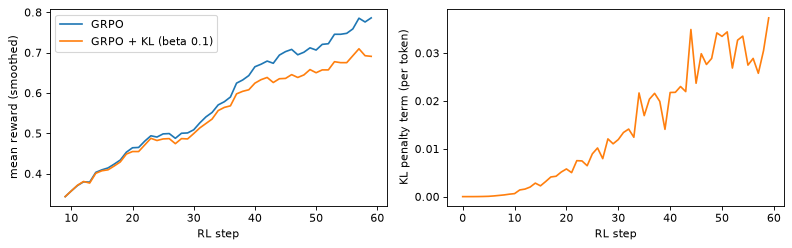

  cat: 'Once upon a time, there was a big cat named Tom. Tom liked to play with a ball. One day, Tom saw a little cat named Sue. Sue was sad because she lost her toy.\nTom wanted to help Sue. He said, "Don\'t worry, Sue. I will help'
  sun: 'Once upon a time, there was a little girl named Lily. She had a big, soft bed. Lily loved to play with her toys and eat yummy food.\nOne day, Lily\'s mom said, "Lily, you need to clean your room." Lily was very happy. She put on her'


 kite: 'Once upon a time, there was a little girl named Lily. She loved to play with her kite. One day, she went to the park with her mom. They saw a big tree with a swing. Lily wanted to play with the kite.\nLily said, " her kite is high in the'
horse: "Once upon a time, there was a little dog named Spot. Spot loved to play with his friends. One day, Spot saw a big ball of yarn. He wanted to play with it, but it was too big.\nSpot's friend, a little girl named Lily, saw him trying to get"


In [12]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
for name, history in [("GRPO", grpo_history), ("GRPO + KL (beta 0.1)", kl_history)]:
    ax[0].plot(np.arange(9, RL_STEPS), smooth(history["reward"]), label=name)
ax[0].set_xlabel("RL step")
ax[0].set_ylabel("mean reward (smoothed)")
ax[0].legend()
ax[1].plot(kl_history["kl"], color="tab:orange")
ax[1].set_xlabel("RL step")
ax[1].set_ylabel("KL penalty term (per token)")
plt.tight_layout()
plt.show()

for topic in ["cat", "sun", "kite", "horse"]:
    out = generate(kl_model, prompt_ids(topic), 60, temperature=0.0, stop_tokens={END})[0]
    print(f"{topic:>5}: {reply_text(out)!r}")

KL 懲罰用一點獎勵換回了「像原本的模型」：KL/token 與 repetition 都比沒有懲罰時低，greedy 的故事也比較自然——代價是有些主題（這裡的 sun、horse）greedy 時又忘了提。$\beta$ 就是這個取捨的旋鈕（講義練習 9）。
注意 KL 從 0 開始慢慢長大：一開始策略就是參考模型，懲罰是 0；策略越走越遠，懲罰才越來越大。

## 5. DPO

偏好資料從 SFT 模型自己的樣本來：20 個訓練主題各抽 10 輪、每輪 8 篇；同一輪裡若有提到與沒提到的，就各隨機取一篇組成 $(y_w, y_l)$。
參考模型 $\pi_{\text{ref}}$ ＝ SFT 模型（凍結）；$\beta = 0.1$、學習率 3e-5（前 10 步 warmup）、batch 16、2 個 epoch。

In [13]:
from lm_course.rl import dpo_loss

g = torch.Generator().manual_seed(2)
rng = random.Random(0)
pairs = []
start = time.perf_counter()
for _ in range(10):
    for topic in STORY_TOPICS:
        prompt = prompt_ids(topic)
        completions = generate(sft_model, prompt, MAX_TOKENS, temperature=1.0, num_samples=8, stop_tokens={END}, generator=g)
        good = [c for c in completions if mentions_topic(topic, reply_text(c))]
        bad = [c for c in completions if not mentions_topic(topic, reply_text(c))]
        if good and bad:
            pairs.append((prompt, rng.choice(good), rng.choice(bad)))
print(f"{len(pairs)} preference pairs from {10 * len(STORY_TOPICS)} rounds ({time.perf_counter() - start:.0f}s)")


def sequence_logprob(model: torch.nn.Module, prompt: list[int], completion: list[int]) -> torch.Tensor:
    logprobs, mask = completion_logprobs(model, prompt, [completion], pad_id=END)
    return (logprobs * mask).sum()


with torch.no_grad():
    reference = [(sequence_logprob(sft_model, p, w), sequence_logprob(sft_model, p, l)) for p, w, l in pairs]

187 preference pairs from 200 rounds (25s)


In [14]:
BETA, DPO_EPOCHS, DPO_BATCH = 0.1, 2, 16
set_seed(0)
dpo_model = copy.deepcopy(sft_model)
optimizer = build_optimizer(dpo_model, "adamw", lr=3e-5, weight_decay=0.0)
order = list(range(len(pairs)))
step = 0
for epoch in range(DPO_EPOCHS):
    random.Random(epoch).shuffle(order)
    dpo_model.train()
    losses, margins, accuracies = [], [], []
    for first in range(0, len(order), DPO_BATCH):
        idx = order[first : first + DPO_BATCH]
        optimizer.set_lr_multiplier(min(1.0, (step + 1) / WARMUP))
        step += 1
        chosen = torch.stack([sequence_logprob(dpo_model, pairs[i][0], pairs[i][1]) for i in idx])
        rejected = torch.stack([sequence_logprob(dpo_model, pairs[i][0], pairs[i][2]) for i in idx])
        ref_chosen = torch.stack([reference[i][0] for i in idx])
        ref_rejected = torch.stack([reference[i][1] for i in idx])
        loss = dpo_loss(chosen, rejected, ref_chosen, ref_rejected, beta=BETA)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(dpo_model.parameters(), 1.0)
        optimizer.step()
        margin = ((chosen - ref_chosen) - (rejected - ref_rejected)).detach()
        losses.append(loss.item())
        margins.append(margin.mean().item())
        accuracies.append((margin > 0).float().mean().item())
    print(f"epoch {epoch + 1}: DPO loss {np.mean(losses):.3f}, log-ratio margin {np.mean(margins):.2f}, "
          f"pairs ranked correctly {np.mean(accuracies):.0%}")
dpo_model.eval()
summary["DPO"] = show("DPO", dpo_model)

epoch 1: DPO loss 0.690, log-ratio margin 0.06, pairs ranked correctly 71%


epoch 2: DPO loss 0.598, log-ratio margin 2.01, pairs ranked correctly 99%


DPO           train    T=1 reward 0.487  greedy 0.750  repetition 0.024  KL/token 0.005
DPO           held-out T=1 reward 0.194  greedy 0.500  repetition 0.021  KL/token 0.003


DPO 的 loss 從 $\ln 2 \approx 0.693$（策略＝參考模型時的值）往下降，訓練配對幾乎全部排對了；但它只看得到這批**固定**的配對，改變模型的幅度也小得多（KL/token 很小）。

## 6. 比較

In [15]:
columns = ["T=1 reward", "greedy", "repetition", "KL/token"]
print(f"{'':<12}| {'train topics':^34} | {'held-out topics':^34}")
print(f"{'model':<12}| " + " ".join(f"{c[:8]:>8}" for c in columns) + " | " + " ".join(f"{c[:8]:>8}" for c in columns))
for name, result in summary.items():
    print(f"{name:<12}| " + " ".join(f"{result['train'][c]:>8.3f}" for c in columns)
          + " | " + " ".join(f"{result['held-out'][c]:>8.3f}" for c in columns))

            |            train topics            |          held-out topics          
model       | T=1 rewa   greedy repetiti KL/token | T=1 rewa   greedy repetiti KL/token
SFT         |    0.362    0.700    0.019    0.000 |    0.131    0.300    0.019    0.000
GRPO        |    0.812    0.950    0.041    0.065 |    0.469    0.600    0.028    0.051
GRPO + KL   |    0.731    0.950    0.028    0.034 |    0.400    0.500    0.024    0.027
DPO         |    0.487    0.750    0.024    0.005 |    0.194    0.500    0.021    0.003


**讀結果時要記得**：一個任務、一組種子、每個主題 16 個樣本；超參數都沒有仔細調。可以確定的是方向：

- **GRPO**（線上）每一步都用模型**自己的新樣本**，一直在它目前的弱點上找訊號，所以進步最多，也走得最遠——包括走向鑽漏洞。
- **KL 懲罰**把「走多遠」變成一個可以調的價錢。
- **DPO**（離線）只用一批固定配對：便宜、穩定、離參考模型很近，但進步也有限；要更多，就要重新抽樣、組新的配對（iterative DPO）。

## 7. 為什麼不拿加法題做 RL？

Lab 11 的加法題看起來是 RL 的理想任務：答案可以驗證、step-by-step 格式常常出錯。開發這個 lab 時，我們先試的就是它——**失敗了**。先量起點：3 位數、step-by-step 格式，greedy 一次、temperature 1 抽 8 次。

In [16]:
from lm_course.chat import addition_problems, addition_reward

seen = {(p.a, p.b) for p in addition_problems(6000, 2, seed=0) + addition_problems(6000, 3, seed=1)}
test3 = addition_problems(50, 3, seed=3, exclude=seen)


def math_prompt(problem) -> list[int]:
    return render_for_completion(tok, [{"role": "user", "content": problem.question("steps")}])


def math_rewards(problem, completions: list[list[int]]) -> list[float]:
    return [addition_reward(problem, reply_text(c)) for c in completions]


g = torch.Generator().manual_seed(0)
greedy, counts = [], []
for p in test3:
    greedy += math_rewards(p, generate(sft_model, math_prompt(p), 90, temperature=0.0, stop_tokens={END}))
    counts.append(sum(math_rewards(p, generate(sft_model, math_prompt(p), 90, temperature=1.0, num_samples=8, stop_tokens={END}, generator=g))))
print(f"greedy accuracy {np.mean(greedy):.2f}, T=1 pass@1 {np.mean([pass_at_k(8, c, 1) for c in counts]):.2f}, "
      f"pass@8 {np.mean([pass_at_k(8, c, 8) for c in counts]):.2f}")

greedy accuracy 0.80, T=1 pass@1 0.22, pass@8 0.74


greedy 遠好於 temperature 1：每一步機率最高的 token 大多是對的，但一個回答有幾十個 token，temperature 1 只要在任何一步抽到機率較低的 token，整題就錯了。把 temperature 1 的錯誤答案分類（50 題 × 8 個樣本）：

In [17]:
import re
from collections import Counter

STEPS_FORMAT = re.compile(r"^(?:\d \+ \d(?: \+ \d)? = \d+, write \d carry \d\. )+(?:Write the carry 1\. )?So \d+ \+ \d+ = \d+\.$")
ONE_STEP = re.compile(r"(\d) \+ (\d)(?: \+ (\d))? = (\d+)")


def error_kind(text: str) -> str:
    if not STEPS_FORMAT.match(text.strip()):
        return "format broken"
    wrong = [(int(a) + int(b) + int(c or 0), int(s)) for a, b, c, s in ONE_STEP.findall(text)
             if int(a) + int(b) + int(c or 0) != int(s)]
    if not wrong:
        return "steps right, a digit copied wrong"
    return "a step off by one" if all(abs(true - said) == 1 for true, said in wrong) else "a step off by more"


g = torch.Generator().manual_seed(0)
kinds, examples = Counter(), {}
for p in test3:
    for completion in generate(sft_model, math_prompt(p), 90, temperature=1.0, num_samples=8, stop_tokens={END}, generator=g):
        if math_rewards(p, [completion])[0]:
            continue
        kind = error_kind(reply_text(completion))
        kinds[kind] += 1
        examples.setdefault(kind, f"{p.a} + {p.b} = {p.answer}\n{reply_text(completion)}")
total = sum(kinds.values())
for kind, n in kinds.most_common():
    print(f"{kind:<34}{n:4d}  ({n / total:.0%} of the wrong answers)")
for kind in ("a step off by one", "format broken"):
    print(f"\n--- example: {kind} ---\n{examples[kind]}")

a step off by one                  155  (50% of the wrong answers)
format broken                      130  (42% of the wrong answers)
a step off by more                  14  (4% of the wrong answers)
steps right, a digit copied wrong   14  (4% of the wrong answers)

--- example: a step off by one ---
243 + 606 = 849
3 + 6 = 9, write 9 carry 0. 4 + 0 + 0 = 4, write 4 carry 0. 2 + 6 + 0 = 9, write 9 carry 0. So 243 + 606 = 949.

--- example: format broken ---
243 + 606 = 849
3 + 6 = 9, write 9 carry 0. 4 + 0 + 0 =  happ in the carry 0. So 24 + 606 = 99.


錯誤分成兩大類，都對 RL 不友善：
- **格式對、某一步差 1**（例如上面把 2 + 6 + 0 寫成 9）：錯誤散在上百個不同的「數字事實」上，每一個在一批 RL 樣本裡只出現幾次。
- **格式整個跑掉**：幾十個 token 裡只要有一步抽到低機率的 token（常常是故事裡的字），後面就接不回來了。

開發時的紀錄（**不是這個 notebook 的輸出**，細節見 `ai-collab/dev_log.md`）：同樣的 GRPO，AdamW 學習率 1e-5 到 1e-4、有沒有 warmup、只訓練 Transformer 區塊、temperature 0.7、改用 SGD——temperature 1 的正確率始終在 0.2 上下，greedy 正確率反而從約 0.8 掉到 0.5–0.7。

梯度到底有沒有指向對的方向？做一個直接的檢查：用 30 題 × 16 個樣本算**一個**大批次的 policy gradient，沿著它（和反著它）走一步，再用同一組隨機數重新量平均獎勵。

In [18]:
problems = addition_problems(30, 3, seed=11, exclude=seen)


def expected_reward(model: torch.nn.Module, n: int = 16) -> float:
    g = torch.Generator().manual_seed(123)  # the same random numbers for every model
    return float(np.mean([np.mean(math_rewards(p, generate(model, math_prompt(p), 90, temperature=1.0, num_samples=n, stop_tokens={END}, generator=g))) for p in problems]))


start = time.perf_counter()
probe = copy.deepcopy(sft_model)
probe.zero_grad()
g = torch.Generator().manual_seed(7)
for p in problems:
    completions = generate(probe, math_prompt(p), 90, temperature=1.0, num_samples=16, stop_tokens={END}, generator=g)
    advantages = group_advantages(torch.tensor(math_rewards(p, completions)))
    if advantages.abs().sum() == 0:
        continue
    logprobs, mask = completion_logprobs(probe, math_prompt(p), completions, pad_id=END)
    (policy_gradient_loss(logprobs, advantages, mask) / len(problems)).backward()

print(f"step size  0.0: mean reward {expected_reward(sft_model):.3f}")
for step_size in (0.5, 2.0, -2.0):
    moved = copy.deepcopy(probe)
    with torch.no_grad():
        for q, q0 in zip(moved.parameters(), probe.parameters()):
            if q0.grad is not None:
                q -= step_size * q0.grad
    print(f"step size {step_size:+.1f}: mean reward {expected_reward(moved):.3f}")
print(f"({time.perf_counter() - start:.0f}s)")

step size  0.0: mean reward 0.246


step size +0.5: mean reward 0.252


step size +2.0: mean reward 0.235


step size -2.0: mean reward 0.069
(69s)


梯度的方向是對的——反著走（負的步長），獎勵大跌；但沿著走，獎勵幾乎不動，步子大一點反而變差。
我們的解讀：在 SFT 模型附近，「變壞」很容易、「變好」的幅度卻很小——要把上百個數字事實各自修好一點點，一批 480 個樣本的訊號遠遠不夠；實際訓練時雜訊主導了更新（Adam 又會把小而雜的梯度放大成固定大小的步伐），模型就被推離了原本會的東西。

對照主題任務：「開頭提到主題」是**一個**所有 prompt 共用的行為，每一批樣本都在推同一個方向，所以 60 步就學得會。

**教訓**：RL 能放大模型已經會、而且樣本裡看得到的行為；訊號太分散、太稀少時，小模型加小批次的 RL 會先學到雜訊。
大模型上的 RLVR 起點完全不同：base model 抽多次常常就解得出來（pass@k 高），每一步用的樣本數也多出好幾個數量級。

## 小結

- 可驗證的獎勵 ＋ 組內平均當 baseline，就是 RLVR 最核心的形式；nanochat 的簡化版就是 REINFORCE。
- 獎勵只是代理：最佳化得越用力，越會被鑽漏洞。KL 懲罰、提早停止、把「不要重複」也寫進獎勵，都是對策。
- DPO 不需要獎勵模型、也不需要在訓練中抽樣，但只學得到固定配對裡的東西。
- RL 不是萬靈丹：先看 pass@k——模型抽很多次都做不到的事，RL 也很難教會。

下一步：[第 13 課](../lessons/13_embedding_models.md)。